In [1]:
# Exploração Inicial — VoughtGuard
# Análise exploratória genérica do dataset de transações (PaySim)

In [2]:
%matplotlib inline

import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import limpeza

sns.set_style("whitegrid")

In [3]:
df = limpeza.carregar_dados("../data/raw/transactions.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
# ## Distribuição por tipo de transação

In [7]:
contagem_tipo = df["type"].value_counts()
contagem_tipo

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

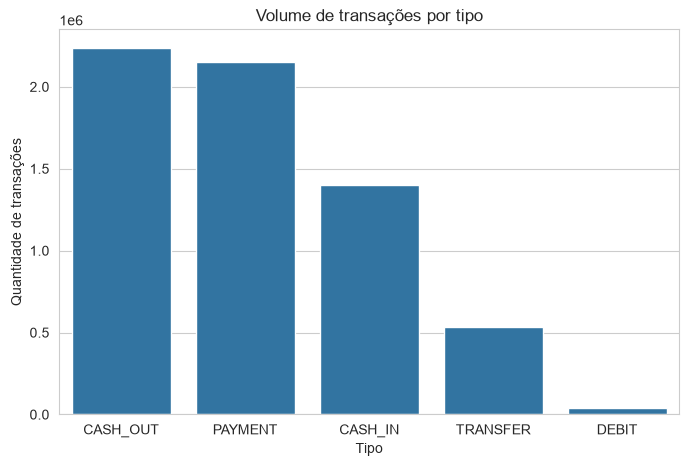

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=contagem_tipo.index, y=contagem_tipo.values)
plt.title("Volume de transações por tipo")
plt.ylabel("Quantidade de transações")
plt.xlabel("Tipo")
plt.show()

In [9]:
# ## Distribuição do valor das transações


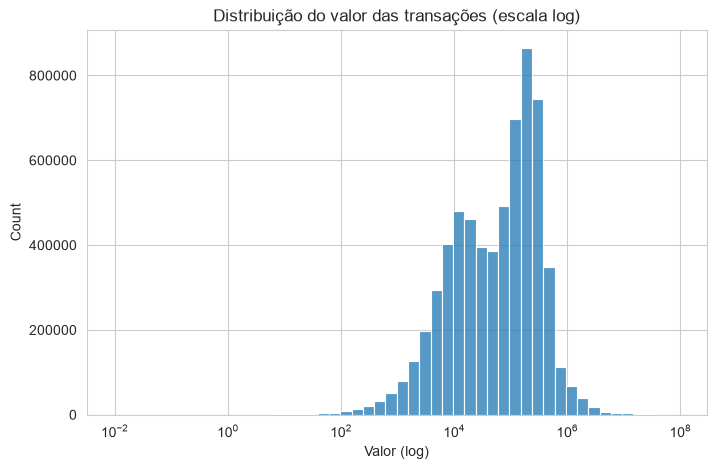

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["amount"], bins=50, log_scale=True)
plt.title("Distribuição do valor das transações (escala log)")
plt.xlabel("Valor (log)")
plt.show()

In [11]:
# ## Proporção geral de fraude na base


In [12]:
taxa_fraude = df["isFraud"].mean() * 100
print(f"Taxa geral de fraude: {taxa_fraude:.4f}%")
print(f"Total de fraudes: {df['isFraud'].sum()}")
print(f"Total de transações: {len(df)}")

Taxa geral de fraude: 0.1291%
Total de fraudes: 8213
Total de transações: 6362620


In [13]:
# **Nota:** este notebook usa os dados brutos (sem limpeza), por isso os números
# de fraude aqui (8.213 fraudes em 6.362.620 transações) diferem levemente dos
# números do pipeline final (8.197 fraudes em 6.362.604 transações, ver
# `relatorio_qualidade.csv`). A diferença de 16 registros corresponde a
# transações fraudulentas com `amount = 0`, removidas na etapa de limpeza.